In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

DATA_PATH = "../data/raw/api_error_logs_with_root_causes_220k_rows.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(220000, 22)


,timestamp,api_name,service_owner,environment,http_method,endpoint,status_code,error_type,root_cause,latency_ms,request_size_bytes,response_size_bytes,retry_count,is_retry_successful,client_ip,region,container_id,host_id,thread_id,log_level,error_message,resolution_action
0,2024-01-01 00:00:00,inventory-api,team-beta,dev,DELETE,/v1/lljugd,503,Timeout,High latency in network,9403,19735,56072,1,True,192.168.97.252,ap-south-1,xuqbiprmtjwu,zjcdzcnlzt,1258,WARN,Internal server error,Refresh token
1,2024-01-01 00:00:05,user-api,team-alpha,staging,DELETE,/v1/mckssy,500,ClientError,Database connection failure,12798,898,47461,2,False,192.168.134.37,us-west-2,tkpvinlsimyz,gcpwfmdubo,8020,INFO,Internal server error,Fix configuration
2,2024-01-01 00:00:10,order-api,team-alpha,prod,DELETE,/v1/ejvxxt,401,AuthError,Schema validation error,1746,42249,69794,4,False,192.168.199.184,us-east-1,tocjxcugfqfx,gqalvwpoum,5427,ERROR,Unauthorized access,Restart service
3,2024-01-01 00:00:15,user-api,team-beta,prod,GET,/v1/noqarz,400,RateLimit,Database connection failure,8021,34209,21193,0,True,192.168.206.244,eu-central-1,lbgdfttkzuto,namadinzvh,8447,WARN,Bad gateway,Optimize query
4,2024-01-01 00:00:20,user-api,team-gamma,prod,GET,/v1/rcqwsq,401,ClientError,Missing authorization scope,4924,11789,46597,0,False,192.168.63.219,us-west-2,oepkhhmcyzlr,nuqorgcfko,8747,WARN,Internal server error,Restart service


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220000 entries, 0 to 219999
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   timestamp            220000 non-null  object
 1   api_name             220000 non-null  object
 2   service_owner        220000 non-null  object
 3   environment          220000 non-null  object
 4   http_method          220000 non-null  object
 5   endpoint             220000 non-null  object
 6   status_code          220000 non-null  int64 
 7   error_type           183229 non-null  object
 8   root_cause           220000 non-null  object
 9   latency_ms           220000 non-null  int64 
 10  request_size_bytes   220000 non-null  int64 
 11  response_size_bytes  220000 non-null  int64 
 12  retry_count          220000 non-null  int64 
 13  is_retry_successful  220000 non-null  bool  
 14  client_ip            220000 non-null  object
 15  region               220000 non-nu

In [4]:
df.columns.tolist()

['timestamp',
 'api_name',
 'service_owner',
 'environment',
 'http_method',
 'endpoint',
 'status_code',
 'error_type',
 'root_cause',
 'latency_ms',
 'request_size_bytes',
 'response_size_bytes',
 'retry_count',
 'is_retry_successful',
 'client_ip',
 'region',
 'container_id',
 'host_id',
 'thread_id',
 'log_level',
 'error_message',
 'resolution_action']

In [5]:
df.isnull().sum().sort_values(ascending=False)

error_type             36771
timestamp                  0
retry_count                0
error_message              0
log_level                  0
thread_id                  0
host_id                    0
container_id               0
region                     0
client_ip                  0
is_retry_successful        0
response_size_bytes        0
api_name                   0
request_size_bytes         0
latency_ms                 0
root_cause                 0
status_code                0
endpoint                   0
http_method                0
environment                0
service_owner              0
resolution_action          0
dtype: int64

In [6]:
df.describe(include="all")

,timestamp,api_name,service_owner,environment,http_method,endpoint,status_code,error_type,root_cause,latency_ms,request_size_bytes,response_size_bytes,retry_count,is_retry_successful,client_ip,region,container_id,host_id,thread_id,log_level,error_message,resolution_action
count,220000,220000,220000,220000,220000,220000,220000.000000,183229,220000,220000.000000,220000.000000,220000.000000,220000.000000,220000,220000,220000,220000,220000,220000.000000,220000,220000,220000
unique,220000,6,4,4,5,219920,NaN,5,15,NaN,NaN,NaN,NaN,2,62801,4,220000,220000,NaN,4,8,8
top,2024-01-01 00:00:00,user-api,team-gamma,dev,DELETE,/v1/wfunzc,NaN,AuthError,Expired authentication token,NaN,NaN,NaN,NaN,True,192.168.228.85,eu-central-1,xuqbiprmtjwu,zjcdzcnlzt,NaN,INFO,Connection refused,Increase timeout
freq,1,36907,55123,55262,44401,2,NaN,36758,14861,NaN,NaN,NaN,NaN,110372,13,55182,1,1,NaN,55274,27840,27710
mean,NaN,NaN,NaN,NaN,NaN,NaN,404.653450,NaN,NaN,7513.061141,25092.098841,40154.401109,1.996118,NaN,NaN,NaN,NaN,NaN,5500.067005,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,100.710925,NaN,NaN,4328.120572,14382.027534,23001.295298,1.414787,NaN,NaN,NaN,NaN,NaN,2595.761985,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,200.000000,NaN,NaN,10.000000,200.000000,200.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1000.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,401.000000,NaN,NaN,3762.000000,12635.000000,20292.000000,1.000000,NaN,NaN,NaN,NaN,NaN,3256.750000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,404.000000,NaN,NaN,7519.000000,25132.500000,40148.000000,2.000000,NaN,NaN,NaN,NaN,NaN,5504.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,500.000000,NaN,NaN,11262.000000,37534.250000,60082.250000,3.000000,NaN,NaN,NaN,NaN,NaN,7745.000000,NaN,NaN,NaN


In [7]:
df.head(10)

,timestamp,api_name,service_owner,environment,http_method,endpoint,status_code,error_type,root_cause,latency_ms,request_size_bytes,response_size_bytes,retry_count,is_retry_successful,client_ip,region,container_id,host_id,thread_id,log_level,error_message,resolution_action
0,2024-01-01 00:00:00,inventory-api,team-beta,dev,DELETE,/v1/lljugd,503,Timeout,High latency in network,9403,19735,56072,1,True,192.168.97.252,ap-south-1,xuqbiprmtjwu,zjcdzcnlzt,1258,WARN,Internal server error,Refresh token
1,2024-01-01 00:00:05,user-api,team-alpha,staging,DELETE,/v1/mckssy,500,ClientError,Database connection failure,12798,898,47461,2,False,192.168.134.37,us-west-2,tkpvinlsimyz,gcpwfmdubo,8020,INFO,Internal server error,Fix configuration
2,2024-01-01 00:00:10,order-api,team-alpha,prod,DELETE,/v1/ejvxxt,401,AuthError,Schema validation error,1746,42249,69794,4,False,192.168.199.184,us-east-1,tocjxcugfqfx,gqalvwpoum,5427,ERROR,Unauthorized access,Restart service
3,2024-01-01 00:00:15,user-api,team-beta,prod,GET,/v1/noqarz,400,RateLimit,Database connection failure,8021,34209,21193,0,True,192.168.206.244,eu-central-1,lbgdfttkzuto,namadinzvh,8447,WARN,Bad gateway,Optimize query
4,2024-01-01 00:00:20,user-api,team-gamma,prod,GET,/v1/rcqwsq,401,ClientError,Missing authorization scope,4924,11789,46597,0,False,192.168.63.219,us-west-2,oepkhhmcyzlr,nuqorgcfko,8747,WARN,Internal server error,Restart service
5,2024-01-01 00:00:25,payment-api,team-alpha,staging,POST,/v1/pnytnt,403,ServerError,Third-party API failure,3721,48597,5330,4,True,192.168.90.182,us-east-1,wpefqceoytku,nmhxmiryut,4349,ERROR,Unauthorized access,Increase timeout
6,2024-01-01 00:00:30,order-api,team-beta,qa,POST,/v1/zcukkq,504,Timeout,Third-party API failure,1764,17566,71696,0,True,192.168.60.12,us-west-2,qyafvybkveta,ogawjlefhr,5930,WARN,Service unavailable,Optimize query
7,2024-01-01 00:00:35,order-api,team-delta,prod,POST,/v1/yquzkq,400,NaN,CPU throttling,3332,14826,45084,1,True,192.168.201.93,us-west-2,soylfljedoty,zqfxxqprcd,4482,CRITICAL,Bad gateway,Retry request
8,2024-01-01 00:00:40,order-api,team-alpha,staging,DELETE,/v1/tmsddv,404,NaN,Deadlock detected,11857,29035,65879,4,False,192.168.139.182,ap-south-1,gprxzxoovmxi,zmqsarhnhy,2989,WARN,Connection refused,Fix configuration
9,2024-01-01 00:00:45,user-api,team-delta,dev,POST,/v1/yxcghg,200,ClientError,Null pointer exception,2245,26620,66394,1,True,192.168.107.183,ap-south-1,frutfxkkaefq,rkbluiufau,4875,CRITICAL,Connection refused,Retry request


In [8]:

df["root_cause"].value_counts()

root_cause
Expired authentication token           14861
Memory exhaustion                      14859
Schema validation error                14843
Null pointer exception                 14772
High latency in network                14758
DNS resolution failure                 14685
SSL handshake failure                  14670
Database connection failure            14620
Misconfigured environment variables    14590
CPU throttling                         14588
Invalid request payload                14565
Deadlock detected                      14551
Third-party API failure                14550
Missing authorization scope            14544
Downstream service unavailable         14544
Name: count, dtype: int64

In [9]:
df["root_cause"].value_counts(normalize=True)

root_cause
Expired authentication token           0.067550
Memory exhaustion                      0.067541
Schema validation error                0.067468
Null pointer exception                 0.067145
High latency in network                0.067082
DNS resolution failure                 0.066750
SSL handshake failure                  0.066682
Database connection failure            0.066455
Misconfigured environment variables    0.066318
CPU throttling                         0.066309
Invalid request payload                0.066205
Deadlock detected                      0.066141
Third-party API failure                0.066136
Missing authorization scope            0.066109
Downstream service unavailable         0.066109
Name: proportion, dtype: float64

In [10]:
df.shape

(220000, 22)

In [11]:
df.nunique().sort_values(ascending=False)

timestamp              220000
host_id                220000
container_id           220000
endpoint               219920
response_size_bytes     74751
client_ip               62801
request_size_bytes      49216
latency_ms              14990
thread_id                8999
root_cause                 15
status_code                12
resolution_action           8
error_message               8
api_name                    6
http_method                 5
retry_count                 5
error_type                  5
region                      4
environment                 4
service_owner               4
log_level                   4
is_retry_successful         2
dtype: int64

In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [13]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["day_of_week"] = df["timestamp"].dt.day_name()

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

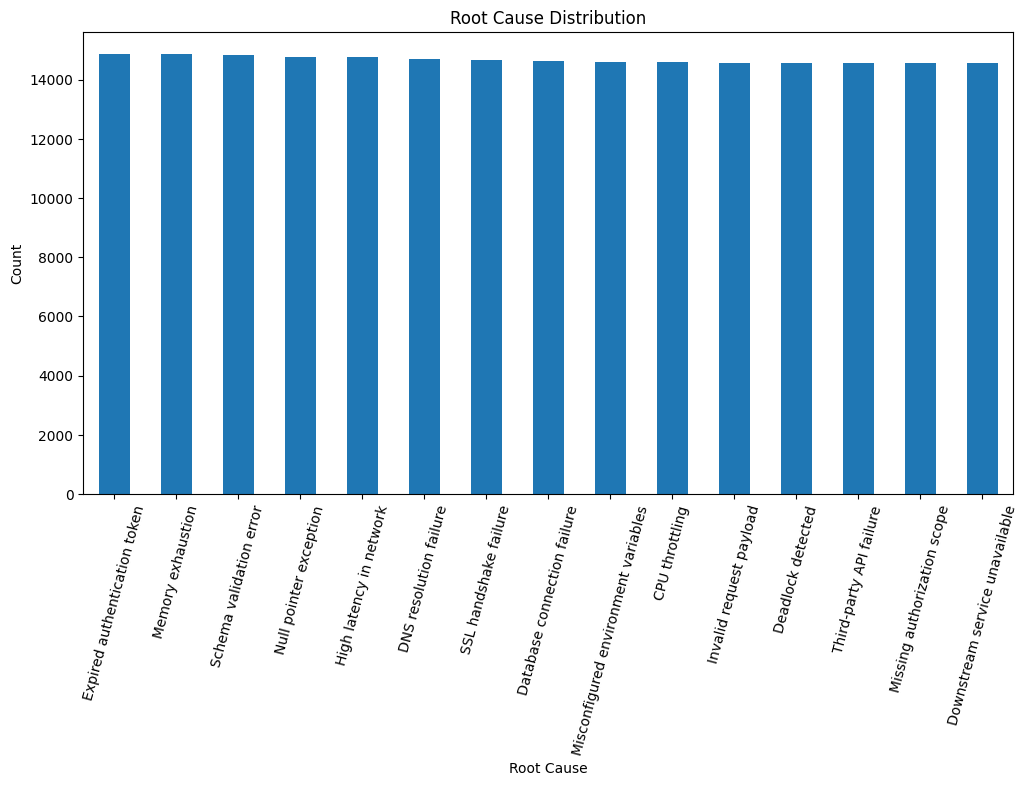

In [15]:
plt.figure(figsize=(12,6))

df["root_cause"].value_counts().plot(kind="bar")

plt.title("Root Cause Distribution")
plt.xlabel("Root Cause")
plt.ylabel("Count")

plt.xticks(rotation=75)

plt.show()

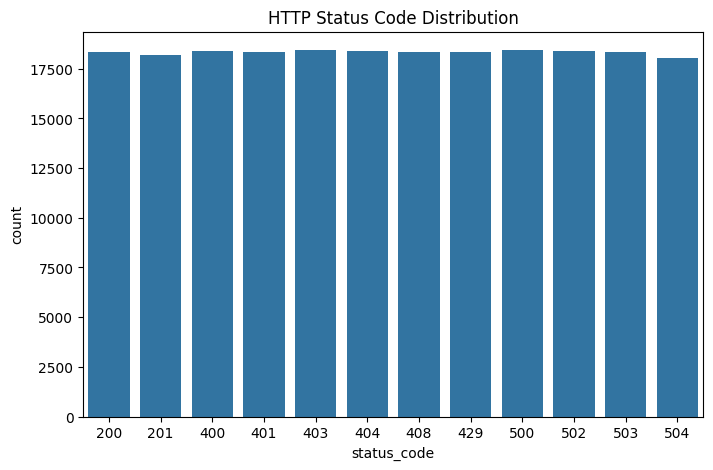

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="status_code")

plt.title("HTTP Status Code Distribution")

plt.show()

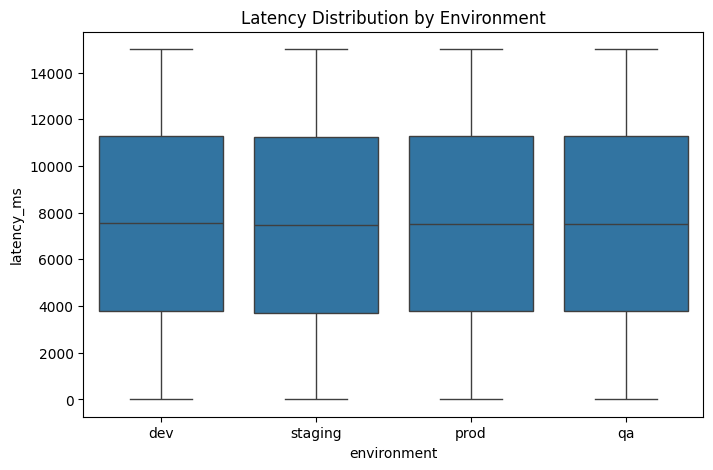

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="environment", y="latency_ms")

plt.title("Latency Distribution by Environment")

plt.show()